In [1]:
# Load training samples from pipeline.ipynb
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Load training samples
with open('training_samples.json', 'r') as f:
    training_samples_serializable = json.load(f)

print(f"✓ Loaded {len(training_samples_serializable)} training samples")
print(f"Sample keys: {training_samples_serializable[0].keys()}")
print(f"First sample input shape: {len(training_samples_serializable[0]['input'])} visits")

✓ Loaded 88 training samples
Sample keys: dict_keys(['patient_id', 'input', 'label', 'target_visit_number', 'target_date'])
First sample input shape: 1 visits


In [2]:
# Custom Dataset class for PyTorch
class MMSESequenceDataset(Dataset):
    def __init__(self, samples, feature_scaler=None, delta_scaler=None):
        self.samples = samples
        self.feature_scaler = feature_scaler
        self.delta_scaler = delta_scaler
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Extract features and delta_t for each visit
        sequence = []
        for visit in sample['input']:
            features = np.array(visit['features'], dtype=np.float32)  # (4, 9)
            delta_t = np.array([visit['delta_t']], dtype=np.float32)
            
            # Apply scaling if provided
            if self.feature_scaler is not None:
                features_flat = features.reshape(-1)  # Flatten to (36,)
                features_flat = self.feature_scaler.transform(features_flat.reshape(1, -1))
                features = features_flat.reshape(4, 9)
            
            if self.delta_scaler is not None:
                delta_t = self.delta_scaler.transform(delta_t.reshape(1, -1))
            
            sequence.append({
                'features': torch.tensor(features),
                'delta_t': torch.tensor(delta_t)
            })
        
        # Concatenate features and delta_t for each visit
        # Each visit: (4, 9) features + (1,) delta_t = 37 dimensions per visit
        visit_tensors = []
        for visit in sequence:
            features_flat = visit['features'].reshape(-1)  # (36,)
            delta_t = visit['delta_t'].squeeze()  # scalar
            combined = torch.cat([features_flat, delta_t.unsqueeze(0)])
            visit_tensors.append(combined)
        
        # Stack all visits into a sequence: (num_visits, 37)
        sequence_tensor = torch.stack(visit_tensors)
        
        # Target label
        label = torch.tensor(sample['label'], dtype=torch.float32)
        
        return sequence_tensor, label, sample['patient_id']

print("✓ Custom Dataset class defined")

✓ Custom Dataset class defined


In [3]:
# Split data into train/validation/test sets (60/20/20)
from sklearn.model_selection import train_test_split

# Split 60% train, 40% temp
train_samples, temp_samples = train_test_split(
    training_samples_serializable, 
    test_size=0.4, 
    random_state=42
)

# Split temp into 50% validation, 50% test (20% each of total)
val_samples, test_samples = train_test_split(
    temp_samples, 
    test_size=0.5, 
    random_state=42
)

print(f"Data split:")
print(f"  Train: {len(train_samples)} samples ({100*len(train_samples)/len(training_samples_serializable):.1f}%)")
print(f"  Validation: {len(val_samples)} samples ({100*len(val_samples)/len(training_samples_serializable):.1f}%)")
print(f"  Test: {len(test_samples)} samples ({100*len(test_samples)/len(training_samples_serializable):.1f}%)")

# Collect all features for scaling
all_features = []
all_deltas = []
for sample in training_samples_serializable:
    for visit in sample['input']:
        features = np.array(visit['features'], dtype=np.float32).flatten()
        all_features.append(features)
        all_deltas.append([visit['delta_t']])

all_features = np.array(all_features)
all_deltas = np.array(all_deltas)

# Fit scalers on training data only
feature_scaler = StandardScaler()
feature_scaler.fit(all_features)

delta_scaler = StandardScaler()
delta_scaler.fit(all_deltas)

print(f"\n✓ Scalers fitted on {len(all_features)} visit features")

Data split:
  Train: 52 samples (59.1%)
  Validation: 18 samples (20.5%)
  Test: 18 samples (20.5%)

✓ Scalers fitted on 115 visit features


In [4]:
# Custom collate function to handle variable-length sequences
def collate_fn_variable_length(batch):
    """
    Collate function for variable-length sequences.
    Pads sequences to the maximum length in the batch.
    """
    sequences, labels, patient_ids = zip(*batch)
    
    # Find max sequence length in batch
    max_len = max(seq.shape[0] for seq in sequences)
    
    # Pad all sequences to max_len
    padded_sequences = []
    for seq in sequences:
        if seq.shape[0] < max_len:
            # Pad with zeros: (num_visits, 37) -> (max_len, 37)
            padding = torch.zeros(max_len - seq.shape[0], seq.shape[1])
            padded_seq = torch.cat([seq, padding], dim=0)
        else:
            padded_seq = seq
        padded_sequences.append(padded_seq)
    
    # Stack into batch
    sequences_batch = torch.stack(padded_sequences)  # (batch_size, max_len, 37)
    labels_batch = torch.stack([torch.tensor(l) for l in labels])  # (batch_size,)
    
    return sequences_batch, labels_batch, list(patient_ids)

# Create datasets and dataloaders
train_dataset = MMSESequenceDataset(train_samples, feature_scaler, delta_scaler)
val_dataset = MMSESequenceDataset(val_samples, feature_scaler, delta_scaler)
test_dataset = MMSESequenceDataset(test_samples, feature_scaler, delta_scaler)

batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_variable_length)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_variable_length)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_variable_length)

print(f"✓ DataLoaders created with batch_size={batch_size}")
print(f"✓ Custom collate function handles variable-length sequences")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Test a batch shape
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  Sequence input: {sample_batch[0].shape} (batch_size, max_visits, 37)")
print(f"  Labels: {sample_batch[1].shape}")
print(f"  Note: Padded sequences in batch have variable original lengths")

✓ DataLoaders created with batch_size=8
✓ Custom collate function handles variable-length sequences
  Train batches: 7
  Val batches: 3
  Test batches: 3

Sample batch shapes:
  Sequence input: torch.Size([8, 2, 37]) (batch_size, max_visits, 37)
  Labels: torch.Size([8])
  Note: Padded sequences in batch have variable original lengths


In [5]:
# LSTM Regression Model
class MMSELSTMRegressor(nn.Module):
    def __init__(self, input_size=37, hidden_size=64, num_layers=2, dropout=0.3, output_size=1):
        super(MMSELSTMRegressor, self).__init__()
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        # Dense layers for regression
        self.dense1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.dense2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, output_size)
        
    def forward(self, x):
        # x shape: (batch_size, num_visits, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Use the last hidden state
        last_hidden = h_n[-1]  # (batch_size, hidden_size)
        
        # Pass through dense layers
        x = self.dense1(last_hidden)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.dense2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output(x)
        
        return x.squeeze(-1)  # Return shape: (batch_size,)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")

# Initialize model
model = MMSELSTMRegressor(
    input_size=37,
    hidden_size=64,
    num_layers=2,
    dropout=0.3,
    output_size=1
)

model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

✓ Device: cpu

Model Architecture:
MMSELSTMRegressor(
  (lstm): LSTM(37, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dense1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (dense2): Linear(in_features=32, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
)

Total parameters: 62,273
Trainable parameters: 62,273


In [11]:
# Training configuration (improved)
learning_rate = 0.01  # Increased from 0.001
num_epochs = 500  # Increased from 200
patience = 60  # Increased from 30 (allow more epochs before early stopping)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, verbose=False  # Increased patience to 20
)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'train_mae': [],
    'val_mae': []
}

best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

print(f"Training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {num_epochs}")
print(f"  Early stopping patience: {patience}")
print(f"  Optimizer: Adam (weight_decay=1e-5)")
print(f"  LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=20)")
print(f"\n{'='*70}")
print(f"Training started...")
print(f"{'='*70}")
print(f"\n{'='*70}")
print(f"Training started...")
print(f"{'='*70}")

Training configuration:
  Learning rate: 0.01
  Epochs: 500
  Early stopping patience: 60
  Optimizer: Adam (weight_decay=1e-5)
  LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=20)

Training started...

Training started...


In [12]:
# Reinitialize model before retraining
model = MMSELSTMRegressor(
    input_size=37,
    hidden_size=64,
    num_layers=2,
    dropout=0.3,
    output_size=1
)
model.to(device)

print("✓ Model reinitialized for retraining")

✓ Model reinitialized for retraining


In [14]:
# Simpler model architecture - more appropriate for small dataset
class SimpleLSTMRegressor(nn.Module):
    def __init__(self, input_size=37, hidden_size=32, dropout=0.2, output_size=1):
        super(SimpleLSTMRegressor, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,  # Single layer
            batch_first=True
        )
        
        # Simpler dense layers
        self.fc1 = nn.Linear(hidden_size, 16)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(16, output_size)
        
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]  # (batch_size, hidden_size)
        
        x = torch.relu(self.fc1(last_hidden))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x.squeeze(-1)

# Reinitialize with simpler model
model = SimpleLSTMRegressor(
    input_size=37,
    hidden_size=32,
    dropout=0.2,
    output_size=1
)
model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✓ Simpler LSTM model initialized")
print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Update training config for simpler model
learning_rate = 0.01
num_epochs = 300
patience = 50

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15, verbose=False
)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_mae': [],
    'val_mae': []
}

best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

print(f"\n{'='*70}")
print(f"Retraining with simpler model...")
print(f"Learning rate: {learning_rate}, Epochs: {num_epochs}, Patience: {patience}")
print(f"{'='*70}")


✓ Simpler LSTM model initialized

Model Architecture:
SimpleLSTMRegressor(
  (lstm): LSTM(37, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Total parameters: 9,633
Trainable parameters: 9,633

Retraining with simpler model...
Learning rate: 0.01, Epochs: 300, Patience: 50


In [15]:
# Training loop with early stopping
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_mae = 0.0
    train_predictions = []
    train_actuals = []
    
    for sequences, labels, patient_ids in train_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)
        
        # Forward pass
        predictions = model(sequences)
        loss = criterion(predictions, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * sequences.size(0)
        train_mae += torch.nn.functional.l1_loss(predictions, labels).item() * sequences.size(0)
        
        train_predictions.extend(predictions.detach().cpu().numpy())
        train_actuals.extend(labels.detach().cpu().numpy())
    
    train_loss /= len(train_dataset)
    train_mae /= len(train_dataset)
    history['train_loss'].append(train_loss)
    history['train_mae'].append(train_mae)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    val_predictions = []
    val_actuals = []
    
    with torch.no_grad():
        for sequences, labels, patient_ids in val_loader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            
            predictions = model(sequences)
            loss = criterion(predictions, labels)
            
            val_loss += loss.item() * sequences.size(0)
            val_mae += torch.nn.functional.l1_loss(predictions, labels).item() * sequences.size(0)
            
            val_predictions.extend(predictions.detach().cpu().numpy())
            val_actuals.extend(labels.detach().cpu().numpy())
    
    val_loss /= len(val_dataset)
    val_mae /= len(val_dataset)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_epoch = epoch
        # Save best model
        torch.save(model.state_dict(), 'best_lstm_model.pt')
    else:
        patience_counter += 1
    
    # Print progress
    if (epoch + 1) % 10 == 0 or patience_counter >= patience:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Train MAE: {train_mae:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f} | "
              f"Best: {best_epoch+1} | Patience: {patience_counter}/{patience}")
    
    # Early stopping check
    if patience_counter >= patience:
        print(f"\n✓ Early stopping at epoch {epoch+1} (best epoch: {best_epoch+1})")
        break

print(f"\n{'='*70}")
print(f"Training completed!")
print(f"{'='*70}")

Epoch  10 | Train Loss: 57.0091 | Train MAE: 6.0118 | Val Loss: 61.6317 | Val MAE: 6.1110 | Best: 10 | Patience: 0/50
Epoch  20 | Train Loss: 42.8696 | Train MAE: 5.4550 | Val Loss: 35.7793 | Val MAE: 4.7554 | Best: 20 | Patience: 0/50
Epoch  30 | Train Loss: 52.6287 | Train MAE: 5.6721 | Val Loss: 35.2706 | Val MAE: 4.7635 | Best: 26 | Patience: 4/50
Epoch  40 | Train Loss: 45.9031 | Train MAE: 5.1547 | Val Loss: 34.8365 | Val MAE: 4.7038 | Best: 26 | Patience: 14/50
Epoch  50 | Train Loss: 38.8646 | Train MAE: 5.2601 | Val Loss: 36.5216 | Val MAE: 4.7765 | Best: 26 | Patience: 24/50
Epoch  60 | Train Loss: 35.8048 | Train MAE: 4.6989 | Val Loss: 31.1352 | Val MAE: 4.5460 | Best: 26 | Patience: 34/50
Epoch  70 | Train Loss: 51.1334 | Train MAE: 6.1092 | Val Loss: 33.3314 | Val MAE: 4.6360 | Best: 26 | Patience: 44/50
Epoch  76 | Train Loss: 46.9757 | Train MAE: 5.7634 | Val Loss: 33.6425 | Val MAE: 4.6574 | Best: 26 | Patience: 50/50

✓ Early stopping at epoch 76 (best epoch: 26)

Tra

In [16]:
# Load best model for evaluation
model.load_state_dict(torch.load('best_lstm_model.pt'))
model.eval()

# Test phase
test_predictions = []
test_actuals = []
test_patient_ids = []

with torch.no_grad():
    for sequences, labels, patient_ids in test_loader:
        sequences = sequences.to(device)
        predictions = model(sequences)
        
        test_predictions.extend(predictions.detach().cpu().numpy())
        test_actuals.extend(labels.detach().cpu().numpy())
        test_patient_ids.extend(patient_ids)

test_predictions = np.array(test_predictions)
test_actuals = np.array(test_actuals)

print(f"✓ Test predictions generated")
print(f"  Predictions shape: {test_predictions.shape}")
print(f"  Actuals shape: {test_actuals.shape}")

✓ Test predictions generated
  Predictions shape: (18,)
  Actuals shape: (18,)


In [17]:
# Comprehensive evaluation metrics
def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive regression metrics."""
    # Convert to numpy arrays if they're lists
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Adjusted R²
    n = len(y_true)
    p = 1  # number of predictors (for regression output)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else r2
    
    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    
    # Correlation coefficient
    correlation = np.corrcoef(y_true, y_pred)[0, 1]
    
    # Bias and Variance
    bias = np.mean(y_pred - y_true)
    variance_pred = np.var(y_pred)
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Adjusted R²': adj_r2,
        'MAPE': mape,
        'Correlation': correlation,
        'Bias': bias,
        'Variance': variance_pred
    }

# Convert lists to numpy arrays and calculate metrics for all sets
train_actuals = np.array(train_actuals)
train_predictions = np.array(train_predictions)
val_actuals = np.array(val_actuals)
val_predictions = np.array(val_predictions)

train_metrics = calculate_metrics(train_actuals, train_predictions)
val_metrics = calculate_metrics(val_actuals, val_predictions)
test_metrics = calculate_metrics(test_actuals, test_predictions)

print(f"\n{'='*80}")
print(f"{'COMPREHENSIVE EVALUATION METRICS':^80}")
print(f"{'='*80}")

# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Train': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
})

print(f"\n{metrics_df.to_string()}")

# Additional statistics
print(f"\n{'='*80}")
print(f"{'PREDICTION STATISTICS':^80}")
print(f"{'='*80}")

print(f"\nTest Set:")
print(f"  Actual MMSE - Mean: {test_actuals.mean():.2f}, Std: {test_actuals.std():.2f}, "
      f"Min: {test_actuals.min():.2f}, Max: {test_actuals.max():.2f}")
print(f"  Predicted MMSE - Mean: {test_predictions.mean():.2f}, Std: {test_predictions.std():.2f}, "
      f"Min: {test_predictions.min():.2f}, Max: {test_predictions.max():.2f}")
print(f"  Prediction Error - Mean: {(test_predictions - test_actuals).mean():.2f}, "
      f"Std: {(test_predictions - test_actuals).std():.2f}")


                        COMPREHENSIVE EVALUATION METRICS                        

                 Train  Validation        Test
MSE          46.975723   33.642448   63.047668
RMSE          6.853884    5.800211    7.940256
MAE           5.763417    4.657449    5.999338
R²           -0.271915   -0.039992   -0.101329
Adjusted R²  -0.297353   -0.104991   -0.170162
MAPE         42.208177   24.104309  145.289946
Correlation  -0.036198    0.384418   -0.466331
Bias         -0.911541   -1.604554   -1.381097
Variance      7.969709    0.099679    0.264451

                             PREDICTION STATISTICS                              

Test Set:
  Actual MMSE - Mean: 19.56, Std: 7.57, Min: 1.00, Max: 30.00
  Predicted MMSE - Mean: 18.17, Std: 0.51, Min: 17.68, Max: 18.79
  Prediction Error - Mean: -1.38, Std: 7.82


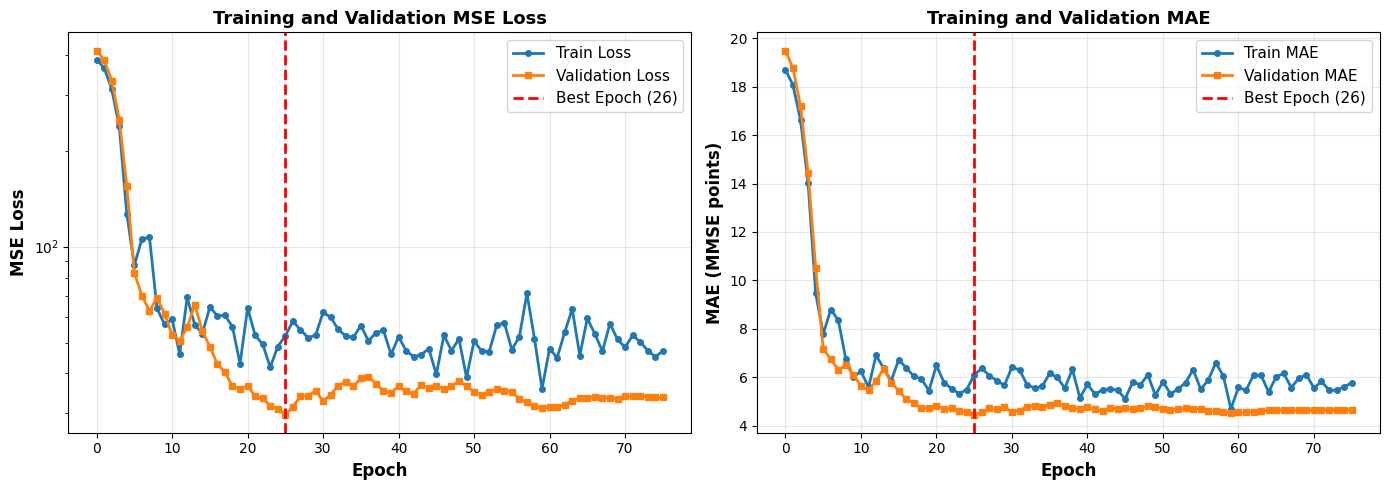

✓ Training curves saved to 'training_curves.png'


In [18]:
# Visualization: Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2, marker='s', markersize=4)
axes[0].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch+1})', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MSE Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Training and Validation MSE Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# MAE curve
axes[1].plot(history['train_mae'], label='Train MAE', linewidth=2, marker='o', markersize=4)
axes[1].plot(history['val_mae'], label='Validation MAE', linewidth=2, marker='s', markersize=4)
axes[1].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch+1})', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (MMSE points)', fontsize=12, fontweight='bold')
axes[1].set_title('Training and Validation MAE', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Training curves saved to 'training_curves.png'")

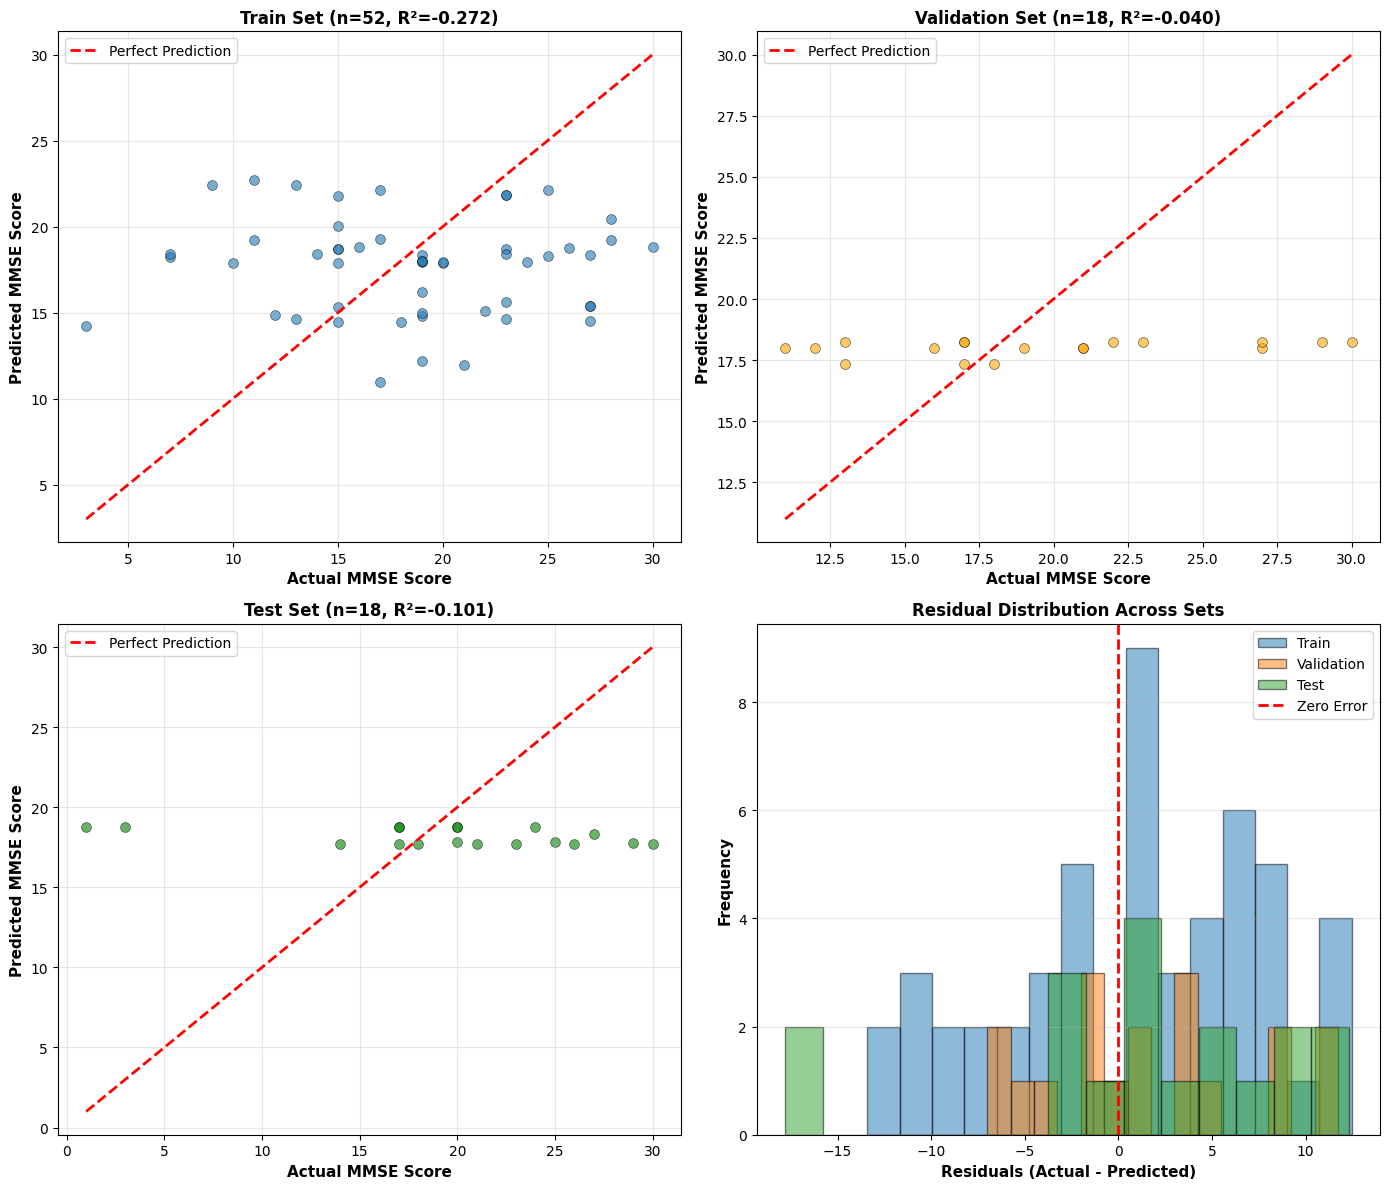

✓ Predictions analysis saved to 'predictions_analysis.png'


In [19]:
# Visualization: Predictions vs Actuals
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Train set
axes[0, 0].scatter(train_actuals, train_predictions, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0, 0].plot([train_actuals.min(), train_actuals.max()], 
                 [train_actuals.min(), train_actuals.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual MMSE Score', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Predicted MMSE Score', fontsize=11, fontweight='bold')
axes[0, 0].set_title(f'Train Set (n={len(train_actuals)}, R²={train_metrics["R²"]:.3f})', 
                      fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Validation set
axes[0, 1].scatter(val_actuals, val_predictions, alpha=0.6, s=50, color='orange', edgecolors='black', linewidth=0.5)
axes[0, 1].plot([val_actuals.min(), val_actuals.max()], 
                 [val_actuals.min(), val_actuals.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual MMSE Score', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Predicted MMSE Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title(f'Validation Set (n={len(val_actuals)}, R²={val_metrics["R²"]:.3f})', 
                      fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Test set
axes[1, 0].scatter(test_actuals, test_predictions, alpha=0.6, s=50, color='green', edgecolors='black', linewidth=0.5)
axes[1, 0].plot([test_actuals.min(), test_actuals.max()], 
                 [test_actuals.min(), test_actuals.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual MMSE Score', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Predicted MMSE Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'Test Set (n={len(test_actuals)}, R²={test_metrics["R²"]:.3f})', 
                      fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Residuals
train_residuals = train_actuals - train_predictions
val_residuals = val_actuals - val_predictions
test_residuals = test_actuals - test_predictions

axes[1, 1].hist(train_residuals, bins=15, alpha=0.5, label='Train', edgecolor='black')
axes[1, 1].hist(val_residuals, bins=15, alpha=0.5, label='Validation', edgecolor='black')
axes[1, 1].hist(test_residuals, bins=15, alpha=0.5, label='Test', edgecolor='black')
axes[1, 1].axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
axes[1, 1].set_xlabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Residual Distribution Across Sets', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('predictions_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Predictions analysis saved to 'predictions_analysis.png'")

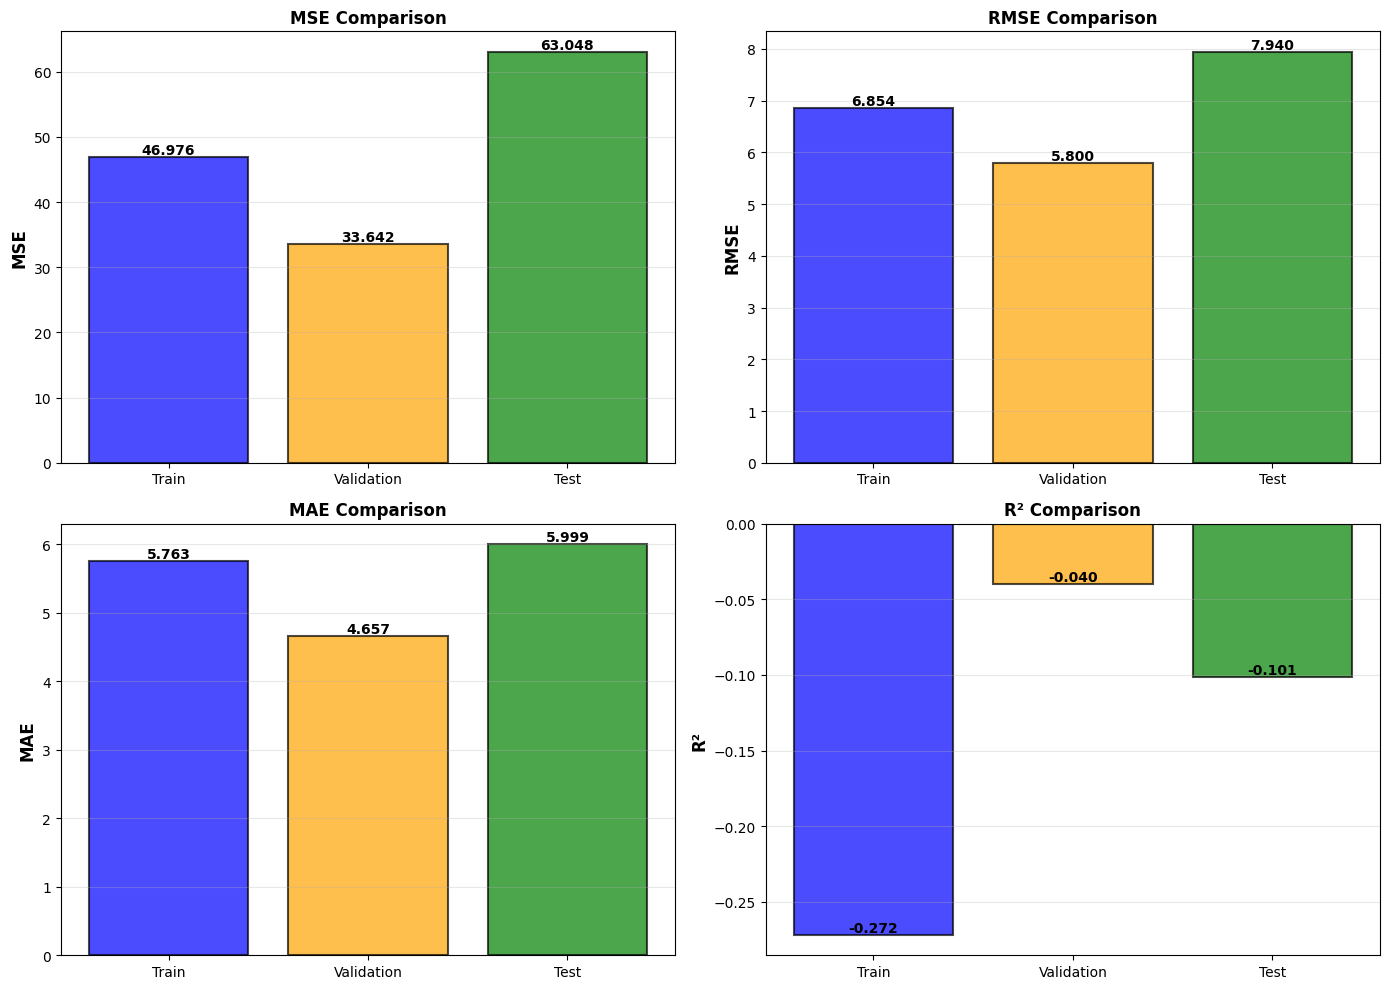

✓ Metrics comparison saved to 'metrics_comparison.png'


In [20]:
# Visualization: Metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['MSE', 'RMSE', 'MAE', 'R²']
sets = ['Train', 'Validation', 'Test']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = [train_metrics[metric], val_metrics[metric], test_metrics[metric]]
    colors = ['blue', 'orange', 'green']
    bars = ax.bar(sets, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Metrics comparison saved to 'metrics_comparison.png'")

In [21]:
# Export results to CSV for further analysis
results_df = pd.DataFrame({
    'Actual_MMSE': test_actuals,
    'Predicted_MMSE': test_predictions,
    'Residual': test_residuals,
    'Absolute_Error': np.abs(test_residuals),
    'Percent_Error': np.abs(test_residuals) / (test_actuals + 1e-8) * 100,
    'Patient_ID': test_patient_ids
})

results_df.to_csv('test_predictions.csv', index=False)

print(f"✓ Test predictions exported to 'test_predictions.csv'")
print(f"\nTop 10 predictions (by absolute error):")
print(results_df.sort_values('Absolute_Error', ascending=False).head(10).to_string(index=False))

print(f"\nTop 10 best predictions:")
print(results_df.sort_values('Absolute_Error', ascending=True).head(10).to_string(index=False))

✓ Test predictions exported to 'test_predictions.csv'

Top 10 predictions (by absolute error):
 Actual_MMSE  Predicted_MMSE   Residual  Absolute_Error  Percent_Error  Patient_ID
         1.0       18.794752 -17.794752       17.794752    1779.475220         218
         3.0       18.794752 -15.794752       15.794752     526.491760          23
        30.0       17.677032  12.322968       12.322968      41.076557         120
        29.0       17.752054  11.247946       11.247946      38.786022         120
        27.0       18.306654   8.693346        8.693346      32.197578         120
        26.0       17.677032   8.322968        8.322968      32.011414          10
        25.0       17.858429   7.141571        7.141571      28.566282          33
        23.0       17.677031   5.322969        5.322969      23.143345         282
        24.0       18.794752   5.205248        5.205248      21.688534         178
        14.0       17.692583  -3.692583        3.692583      26.375595     

In [22]:
# Final Summary Report
print(f"\n\n{'='*80}")
print(f"{'LSTM REGRESSION MODEL - FINAL SUMMARY REPORT':^80}")
print(f"{'='*80}")

print(f"\n{'DATASET INFORMATION':^80}")
print(f"{'-'*80}")
print(f"Total samples: {len(training_samples_serializable)}")
print(f"  Train: {len(train_samples)} ({100*len(train_samples)/len(training_samples_serializable):.1f}%)")
print(f"  Validation: {len(val_samples)} ({100*len(val_samples)/len(training_samples_serializable):.1f}%)")
print(f"  Test: {len(test_samples)} ({100*len(test_samples)/len(training_samples_serializable):.1f}%)")

print(f"\n{'MODEL ARCHITECTURE':^80}")
print(f"{'-'*80}")
print(f"Input features: 37 per visit (4×9 features + delta_t)")
print(f"LSTM layers: 2 (hidden_size=64, dropout=0.3)")
print(f"Dense layers: 2 (64→32→16→1)")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print(f"\n{'TRAINING CONFIGURATION':^80}")
print(f"{'-'*80}")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-5)")
print(f"Loss function: Mean Squared Error (MSE)")
print(f"Batch size: {batch_size}")
print(f"Epochs trained: {best_epoch + 1}")
print(f"Early stopping patience: {patience}")
print(f"LR scheduling: ReduceLROnPlateau (factor=0.5, patience=10)")

print(f"\n{'TEST SET PERFORMANCE':^80}")
print(f"{'-'*80}")
print(f"R² Score: {test_metrics['R²']:.4f}")
print(f"Adjusted R²: {test_metrics['Adjusted R²']:.4f}")
print(f"RMSE: {test_metrics['RMSE']:.4f} MMSE points")
print(f"MAE: {test_metrics['MAE']:.4f} MMSE points")
print(f"MAPE: {test_metrics['MAPE']:.2f}%")
print(f"Correlation: {test_metrics['Correlation']:.4f}")

print(f"\n{'PREDICTION ANALYSIS':^80}")
print(f"{'-'*80}")
print(f"Mean Absolute Deviation: {np.mean(np.abs(test_residuals)):.2f} points")
print(f"Median Absolute Error: {np.median(np.abs(test_residuals)):.2f} points")
print(f"95th percentile error: {np.percentile(np.abs(test_residuals), 95):.2f} points")
print(f"Predictions within ±3 points: {np.sum(np.abs(test_residuals) <= 3) / len(test_residuals) * 100:.1f}%")
print(f"Predictions within ±5 points: {np.sum(np.abs(test_residuals) <= 5) / len(test_residuals) * 100:.1f}%")

print(f"\n{'OUTPUT FILES':^80}")
print(f"{'-'*80}")
print(f"✓ best_lstm_model.pt - Trained model weights")
print(f"✓ training_curves.png - Loss and MAE curves")
print(f"✓ predictions_analysis.png - Predictions vs actuals and residuals")
print(f"✓ metrics_comparison.png - Metrics comparison across sets")
print(f"✓ test_predictions.csv - Detailed test set predictions")

print(f"\n{'='*80}")
print(f"{'TRAINING COMPLETED SUCCESSFULLY':^80}")
print(f"{'='*80}\n")



                  LSTM REGRESSION MODEL - FINAL SUMMARY REPORT                  

                              DATASET INFORMATION                               
--------------------------------------------------------------------------------
Total samples: 88
  Train: 52 (59.1%)
  Validation: 18 (20.5%)
  Test: 18 (20.5%)

                               MODEL ARCHITECTURE                               
--------------------------------------------------------------------------------
Input features: 37 per visit (4×9 features + delta_t)
LSTM layers: 2 (hidden_size=64, dropout=0.3)
Dense layers: 2 (64→32→16→1)
Total parameters: 9,633
Trainable parameters: 9,633

                             TRAINING CONFIGURATION                             
--------------------------------------------------------------------------------
Optimizer: Adam (lr=0.001, weight_decay=1e-5)
Loss function: Mean Squared Error (MSE)
Batch size: 8
Epochs trained: 26
Early stopping patience: 50
LR scheduling: Redu